# 04 — Interprétabilité SHAP comparative

**Mini-projet IA Responsable — Phase 3 / 5**

On utilise [SHAP](https://shap.readthedocs.io/) (valeurs de Shapley, théorie des jeux coopératifs) pour expliquer les prédictions au niveau **token** des trois modèles :

| Modèle | Source |
|---|---|
| `baseline` | `reports/checkpoints/baseline_bert/` (P1) |
| `fair_weighted` | `reports/checkpoints/fair_weighted/` (P2 — variante A) |
| `fair_multitask` | `reports/checkpoints/fair_multitask/` (P2 — variante B) |

**Objectif audit** : vérifier si la mitigation (A, B) réduit effectivement le **poids attribué aux tokens identitaires** dans la décision. Métrique clé :
$$\text{IdRatio}(M) = \frac{\mathbb{E}_{\text{ex}}\left[\sum_{t \in \text{identités}} |\text{SHAP}(t)| \right]}{\mathbb{E}_{\text{ex}}\left[\sum_t |\text{SHAP}(t)| \right]}$$

Une mitigation efficace doit faire **baisser** `IdRatio(fair) < IdRatio(baseline)`.

---

**Sommaire**

0. Setup & configuration
1. Vocabulaire identitaire
2. Chargement test + échantillon stratifié (BPSN/BNSP forcés)
3. Helpers SHAP (predict, agrégation, normalisation tokens)
4. Définition du modèle multi-tâches (pour reload P2-B)
5. Pipeline SHAP × 3 modèles
6. Analyse globale comparée (top-K, IdRatio, heatmap par identité)
7. Comparaisons locales (HTML waterfall side-by-side)
8. Sauvegarde + diagnostic


## 0. Setup & configuration


In [5]:
import gc
import html as _html
import json
import os
import random
import re
import warnings
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

os.environ.setdefault("USE_TF", "0")
os.environ.setdefault("USE_FLAX", "0")
os.environ.setdefault("USE_TORCH", "1")

import shap
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BertModel,
    BertPreTrainedModel,
)
from transformers.modeling_outputs import ModelOutput

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"shap   : {shap.__version__}")


Device : cuda
shap   : 0.50.0


In [6]:
# === Chemins ===
DATA_DIR = Path(
    os.environ.get("JIGSAW_DATA_DIR",
                   "../data")
).expanduser().resolve()
TRAIN_CSV = DATA_DIR / "train.csv"

REPORTS_DIR = Path("../reports").resolve()
SPLITS_DIR  = REPORTS_DIR / "splits"
METRICS_DIR = REPORTS_DIR / "metrics"
FIGURES_DIR = REPORTS_DIR / "figures"
SHAP_DIR    = REPORTS_DIR / "shap"
SHAP_LOCAL_DIR = SHAP_DIR / "local_html"
for p in (SHAP_DIR, SHAP_LOCAL_DIR, METRICS_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

MODELS = {
    "baseline":       REPORTS_DIR / "checkpoints" / "baseline_bert",
    "fair_weighted":  REPORTS_DIR / "checkpoints" / "fair_weighted",
    "fair_multitask": REPORTS_DIR / "checkpoints" / "fair_multitask",
}
for name, path in MODELS.items():
    print(f"  {name:<14s} {path}   exists={path.exists()}")

# === Hyperparamètres SHAP ===
SEED        = 1337
MAX_LEN     = 128
BATCH_SIZE  = 32         # inférence pour SHAP
N_EXAMPLES  = 30         # nb commentaires expliqués (× 3 modèles)
MAX_EVALS   = 200        # nb permutations SHAP / exemple — équilibre précision / temps
SHAP_BATCH  = 16         # batch interne pour les appels du masker
MIN_TEST_PER_IDENTITY = 500   # cohérence avec P1/P2

LABEL_THRESHOLD    = 0.5
IDENTITY_THRESHOLD = 0.5

# Reproductibilité
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def free_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


  baseline       C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\baseline_bert   exists=True
  fair_weighted  C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_weighted   exists=True
  fair_multitask C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\checkpoints\fair_multitask   exists=True


## 1. Vocabulaire identitaire

On définit une liste **explicite et curée** de termes identitaires (24 colonnes Jigsaw + variantes pluriel/singulier + termes proches). C'est le matériel de l'audit : ces mots sont ceux dont le poids dans la prédiction doit *idéalement* être faible après mitigation, surtout en contexte non-toxique.


In [7]:
IDENTITY_COLS = [
    "asian", "atheist", "bisexual", "black", "buddhist", "christian", "female",
    "heterosexual", "hindu", "homosexual_gay_or_lesbian",
    "intellectual_or_learning_disability", "jewish", "latino", "male", "muslim",
    "other_disability", "other_gender", "other_race_or_ethnicity", "other_religion",
    "other_sexual_orientation", "physical_disability", "psychiatric_or_mental_illness",
    "transgender", "white",
]
N_ID = len(IDENTITY_COLS)

# Vocabulaire identitaire détaillé (mappé sur les catégories Jigsaw).
# Lowercase, sans accent, sans ponctuation — sera comparé au token normalisé.
IDENTITY_LEXICON = {
    "gender_female": {"female", "females", "woman", "women", "girl", "girls", "she", "her", "hers", "mom", "mother", "mothers", "wife", "wives", "lady", "ladies"},
    "gender_male":   {"male", "males", "man", "men", "boy", "boys", "he", "him", "his", "dad", "father", "fathers", "husband", "husbands", "guy", "guys"},
    "gender_trans":  {"transgender", "trans", "transsexual", "transwoman", "transman", "non-binary", "nonbinary", "genderqueer"},
    "sexual_lgbt":   {"gay", "gays", "lesbian", "lesbians", "homosexual", "homosexuals", "queer", "queers", "bi", "bisexual", "bisexuals", "lgbt", "lgbtq", "lgbtqia"},
    "sexual_hetero": {"straight", "heterosexual", "heterosexuals"},
    "religion_christian": {"christian", "christians", "christianity", "catholic", "catholics", "catholicism", "protestant", "protestants", "evangelical", "evangelicals"},
    "religion_jewish":    {"jew", "jews", "jewish", "judaism", "hebrew", "hebrews", "israelite", "israeli", "israelis"},
    "religion_muslim":    {"muslim", "muslims", "islam", "islamic", "islamist", "islamists", "arab", "arabs"},
    "religion_hindu":     {"hindu", "hindus", "hinduism"},
    "religion_buddhist":  {"buddhist", "buddhists", "buddhism", "buddha"},
    "religion_atheist":   {"atheist", "atheists", "atheism", "secular", "secularist"},
    "race_black":         {"black", "blacks", "african", "afro", "african-american", "africanamerican", "negro"},
    "race_white":         {"white", "whites", "caucasian", "caucasians", "anglo", "european"},
    "race_asian":         {"asian", "asians", "oriental", "orientals", "chinese", "japanese", "korean"},
    "race_latino":        {"latino", "latinos", "latina", "latinas", "latinx", "hispanic", "hispanics", "mexican", "mexicans"},
    "disability":         {"disabled", "disability", "disabilities", "handicapped", "wheelchair", "blind", "deaf", "autistic", "autism"},
    "mental":             {"crazy", "insane", "psycho", "psychotic", "schizophrenic", "schizo", "depressed", "depression", "mentally"},
}

IDENTITY_KEYWORDS = set().union(*IDENTITY_LEXICON.values())
print(f"Vocabulaire identitaire : {len(IDENTITY_KEYWORDS)} termes, {len(IDENTITY_LEXICON)} catégories")


Vocabulaire identitaire : 143 termes, 17 catégories


## 2. Chargement test + échantillon stratifié

On rejoue les splits P1 et on échantillonne `N_EXAMPLES` commentaires test, **stratifiés par (toxique × any_identity)** avec un quota minimal sur les cas BPSN (non-toxique avec identité — c'est là que le biais FP se manifeste) et BNSP (toxique sans identité — utile pour comparer).


In [8]:
assert TRAIN_CSV.exists(), f"Fichier introuvable: {TRAIN_CSV}"
splits_path = SPLITS_DIR / "split_ids.json"
assert splits_path.exists(), f"Splits introuvables: {splits_path}"

with open(splits_path, encoding="utf-8") as f:
    splits = json.load(f)
print(f"Splits chargés : test = {len(splits['test']):,}")

USE_COLS = ["id", "comment_text", "target"] + IDENTITY_COLS
test_ids = set(splits["test"])
df_full = pd.read_csv(TRAIN_CSV, usecols=USE_COLS)
test_df = df_full[df_full["id"].isin(test_ids)].set_index("id").loc[splits["test"]].reset_index()
del df_full; gc.collect()
print(f"Test : {len(test_df):,} lignes rechargées")

# Labels + flags
test_df["label"] = (test_df["target"].fillna(0) >= LABEL_THRESHOLD).astype(int)
for c in IDENTITY_COLS:
    test_df[c + "_bin"] = (test_df[c].fillna(0) >= IDENTITY_THRESHOLD).astype(int)
test_df["any_identity"] = test_df[[c + "_bin" for c in IDENTITY_COLS]].max(axis=1)
test_df["group"] = (
    test_df["label"].astype(str) + "_" + test_df["any_identity"].astype(str)
)
print(test_df["group"].value_counts().rename({
    "0_0": "non-tox × sans-id", "0_1": "non-tox × identité (BPSN)",
    "1_0": "toxique × sans-id (BNSP)", "1_1": "toxique × identité",
}))


Splits chargés : test = 180,491
Test : 180,491 lignes rechargées
group
non-tox × sans-id            151821
non-tox × identité (BPSN)     14235
toxique × sans-id (BNSP)      11638
toxique × identité             2797
Name: count, dtype: int64


In [9]:
# Échantillonnage stratifié avec quotas explicites
# (force la présence de cas BPSN et BNSP)
QUOTAS = {
    "0_1": 12,   # non-toxique × identité (BPSN — risque FP)
    "1_1":  8,   # toxique × identité
    "1_0":  6,   # toxique × sans-id (BNSP)
    "0_0":  4,   # neutre
}
assert sum(QUOTAS.values()) == N_EXAMPLES, f"Quotas != N_EXAMPLES ({N_EXAMPLES})"

rng = np.random.default_rng(SEED)
sample_chunks = []
for g, n in QUOTAS.items():
    sub = test_df[test_df["group"] == g]
    n_take = min(n, len(sub))
    sample_chunks.append(sub.sample(n=n_take, random_state=SEED))
sample_df = pd.concat(sample_chunks, ignore_index=True)
sample_df = sample_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(f"Échantillon : {len(sample_df)} commentaires")
print(sample_df["group"].value_counts())
print("\nAperçu :")
for i, row in sample_df.head(5).iterrows():
    txt = str(row["comment_text"])[:100].replace("\n", " ")
    print(f"  [{row['group']}] {txt}…")

# Persiste les IDs pour traçabilité
sample_ids_path = SHAP_DIR / "sample_ids.json"
with open(sample_ids_path, "w", encoding="utf-8") as f:
    json.dump({"ids": sample_df["id"].astype(int).tolist(),
               "groups": sample_df["group"].tolist(),
               "quotas": QUOTAS}, f, indent=2)
print(f"\nIDs sauvegardés : {sample_ids_path}")


Échantillon : 30 commentaires
group
0_1    12
1_1     8
1_0     6
0_0     4
Name: count, dtype: int64

Aperçu :
  [0_1] Regarding [1] WOW...I guess man can convince himself of anything...#MAGA…
  [1_1] Then you never had one. Richard Spencer is literally a white supremacist. The fact you want to argue…
  [0_1] Support for Planned Parenthood while voting for every other traitorous Republican scheme to deny hum…
  [1_1] Seriously looking at this picture, if she can wear that anywhere, than Halloween masks should be all…
  [0_1] This appears to be true.  But the issue is free speech.  She should be free to espouse whatever she …

IDs sauvegardés : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\shap\sample_ids.json


## 3. Helpers SHAP (predict, agrégation, normalisation)


In [18]:
_PUNCT_RE = re.compile(r"[^a-z0-9'-]+")

def normalize_token(t: str) -> str:
    """Standardise un token pour matching : lowercase, strip ##/Ġ, retire ponctuation."""
    s = str(t).strip().lower()
    s = s.lstrip("##").lstrip("Ġ").strip()
    s = _PUNCT_RE.sub("", s)
    return s


def is_identity_token(t: str) -> bool:
    return normalize_token(t) in IDENTITY_KEYWORDS


def token_category(t: str) -> Optional[str]:
    n = normalize_token(t)
    for cat, vocab in IDENTITY_LEXICON.items():
        if n in vocab:
            return cat
    return None


def make_predict_fn(model, tokenizer, *, max_length=MAX_LEN, batch_size=SHAP_BATCH, device=DEVICE):
    """Construit la fonction predict_proba consommée par shap.Explainer.

    Signature attendue : (texts: np.ndarray[str]) -> np.ndarray (N,) probas P(toxic)."""
    model.to(device).eval()
    model.requires_grad_(False)

    def predict(texts):
        if isinstance(texts, np.ndarray):
            texts_list = [str(t) for t in texts.tolist()]
        else:
            texts_list = [str(t) for t in texts]
        probs = []
        with torch.inference_mode():
            for i in range(0, len(texts_list), batch_size):
                batch = texts_list[i:i + batch_size]
                enc = tokenizer(batch, truncation=True, padding=True,
                                max_length=max_length, return_tensors="pt")
                enc = {k: v.to(device) for k, v in enc.items()}
                out = model(**enc)
                logits = out.logits
                if logits.ndim == 2 and logits.shape[-1] > 1:
                    batch_probs = torch.softmax(logits, dim=-1)[:, 1]
                else:
                    batch_probs = torch.sigmoid(logits.reshape(-1))
                probs.append(batch_probs.cpu().numpy())
        return np.concatenate(probs, axis=0)
    return predict


In [19]:
def aggregate_shap(shap_values) -> dict:
    """
    Pour un SHAP Explanation (sortie de explainer(texts)) :
      - token_mean_abs : dict token_norm -> moyenne |SHAP| sur l'échantillon
      - example_id_share : array N (somme |SHAP| sur tokens identitaires / somme |SHAP| total) par exemple
      - id_global_ratio : ratio global (somme totale)
      - per_category : dict catégorie -> somme |SHAP| (et count)
    """
    token_vals = defaultdict(list)
    example_id_share = []
    sum_id_global = 0.0
    sum_total_global = 0.0
    per_category = defaultdict(lambda: {"sum_abs_shap": 0.0, "count": 0})

    for i in range(len(shap_values)):
        toks = shap_values.data[i]
        vals = shap_values.values[i]
        if vals.ndim > 1:
            # shap renvoie parfois (n_tokens, n_classes) — on prend le scalaire
            vals = vals.squeeze()
            if vals.ndim > 1:
                vals = vals[:, -1]  # dernière classe = toxic

        total_abs = 0.0
        id_abs = 0.0
        for tok, val in zip(toks, vals):
            n = normalize_token(tok)
            if not n:
                continue
            v = float(abs(val))
            total_abs += v
            token_vals[n].append(v)
            cat = token_category(tok)
            if cat is not None:
                id_abs += v
                per_category[cat]["sum_abs_shap"] += v
                per_category[cat]["count"] += 1
        sum_total_global += total_abs
        sum_id_global += id_abs
        share = (id_abs / total_abs) if total_abs > 0 else 0.0
        example_id_share.append(share)

    token_mean_abs = {k: float(np.mean(v)) for k, v in token_vals.items()}
    return {
        "token_mean_abs": token_mean_abs,
        "example_id_share": np.array(example_id_share, dtype=float),
        "id_global_ratio": (sum_id_global / sum_total_global) if sum_total_global > 0 else 0.0,
        "per_category": {k: dict(v) for k, v in per_category.items()},
        "sum_id_global": sum_id_global,
        "sum_total_global": sum_total_global,
    }


## 4. Définition du modèle multi-tâches (pour reload `fair_multitask`)


In [20]:
@dataclass
class ToxicityIdentityOutput(ModelOutput):
    loss: Optional[torch.Tensor] = None
    logits: Optional[torch.Tensor] = None
    identity_logits: Optional[torch.Tensor] = None


class BertForToxicityAndIdentity(BertPreTrainedModel):
    def __init__(self, config, num_identities: int = N_ID):
        super().__init__(config)
        self.num_identities = int(num_identities)
        self.bert = BertModel(config, add_pooling_layer=True)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.toxicity_classifier = nn.Linear(config.hidden_size, 1)
        self.identity_classifier = nn.Linear(config.hidden_size, self.num_identities)
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, **kwargs):
        outputs = self.bert(
            input_ids=input_ids, attention_mask=attention_mask,
            token_type_ids=token_type_ids, **kwargs,
        )
        pooled = self.dropout(outputs.pooler_output)
        tox_logits = self.toxicity_classifier(pooled).squeeze(-1)
        id_logits  = self.identity_classifier(pooled)
        return ToxicityIdentityOutput(logits=tox_logits, identity_logits=id_logits)


def load_model(label: str):
    path = MODELS[label]
    assert path.exists(), f"Modèle introuvable: {path}"
    if label == "fair_multitask":
        model = BertForToxicityAndIdentity.from_pretrained(str(path), num_identities=N_ID)
    else:
        model = AutoModelForSequenceClassification.from_pretrained(str(path))
    tok = AutoTokenizer.from_pretrained(str(path), use_fast=True)
    return model, tok


## 5. Pipeline SHAP × 3 modèles

Pour chaque modèle on :
1. Charge le checkpoint + le tokenizer.
2. Initialise `shap.Explainer(predict_proba, shap.maskers.Text(tokenizer))`.
3. Calcule les `shap_values` sur l'échantillon (~30 commentaires × MAX_EVALS=200 forward passes ≈ 6 000 / modèle).
4. Sauvegarde les HTML locaux.
5. Calcule l'agrégat global.
6. Libère la VRAM.

⏱️ Temps estimé : ~3-5 min par modèle sur RTX 4080.


In [21]:
def run_shap_for_model(label: str, texts: list[str]) -> dict:
    print(f"\n=== SHAP — {label} ===")
    model, tok = load_model(label)
    predict_fn = make_predict_fn(model, tok, max_length=MAX_LEN, batch_size=SHAP_BATCH)
    masker = shap.maskers.Text(tok)
    explainer = shap.Explainer(predict_fn, masker)
    print(f"  Calcul SHAP sur {len(texts)} exemples (max_evals={MAX_EVALS}) …")
    shap_values = explainer(texts, max_evals=MAX_EVALS)

    # Sauvegarde HTML locaux par exemple
    out_dir = SHAP_LOCAL_DIR / label
    out_dir.mkdir(parents=True, exist_ok=True)
    for i in range(len(texts)):
        try:
            html_obj = shap.plots.text(shap_values[i], display=False)
        except TypeError:
            html_obj = shap.plots.text(shap_values[i])
        content = getattr(html_obj, "data", None) or str(html_obj)
        (out_dir / f"shap_{i:03d}.html").write_text(content, encoding="utf-8")

    # Agrégation
    agg = aggregate_shap(shap_values)
    print(f"  IdRatio global         : {agg['id_global_ratio']:.4f}")
    print(f"  Mean per-example share : {agg['example_id_share'].mean():.4f}")
    print(f"  HTML écrits dans       : {out_dir}")

    # Libère
    del model, tok, predict_fn, explainer, masker
    free_cuda()

    return {"label": label, "shap_values": shap_values, "agg": agg, "out_dir": str(out_dir)}


texts_sample = sample_df["comment_text"].astype(str).tolist()
labels_sample = sample_df["label"].astype(int).tolist()
groups_sample = sample_df["group"].tolist()

results = {}
for label in ["baseline", "fair_weighted", "fair_multitask"]:
    if not MODELS[label].exists():
        print(f"[skip] {label} introuvable ({MODELS[label]})")
        continue
    results[label] = run_shap_for_model(label, texts_sample)



=== SHAP — baseline ===
  Calcul SHAP sur 30 exemples (max_evals=200) …


PartitionExplainer explainer: 31it [00:20,  1.21s/it]                        


  IdRatio global         : 0.0632
  Mean per-example share : 0.0699
  HTML écrits dans       : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\shap\local_html\baseline

=== SHAP — fair_weighted ===
  Calcul SHAP sur 30 exemples (max_evals=200) …


PartitionExplainer explainer: 31it [00:20,  1.23s/it]                        


  IdRatio global         : 0.0529
  Mean per-example share : 0.0668
  HTML écrits dans       : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\shap\local_html\fair_weighted

=== SHAP — fair_multitask ===
  Calcul SHAP sur 30 exemples (max_evals=200) …


PartitionExplainer explainer: 31it [00:20,  1.21s/it]                        


  IdRatio global         : 0.0603
  Mean per-example share : 0.0775
  HTML écrits dans       : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\shap\local_html\fair_multitask


## 6. Analyse globale comparée

Trois angles :
1. **IdRatio global** : un seul nombre par modèle ⇒ barre comparative directe.
2. **Distribution par exemple** : box-plot de `|SHAP|_id / |SHAP|_total` ⇒ révèle la variance.
3. **Top tokens** : quels mots dominent réellement la décision ? Top-30 par modèle + croisement avec le vocabulaire identitaire.
4. **Heatmap par catégorie identitaire** : où se concentre le résidu de biais ?


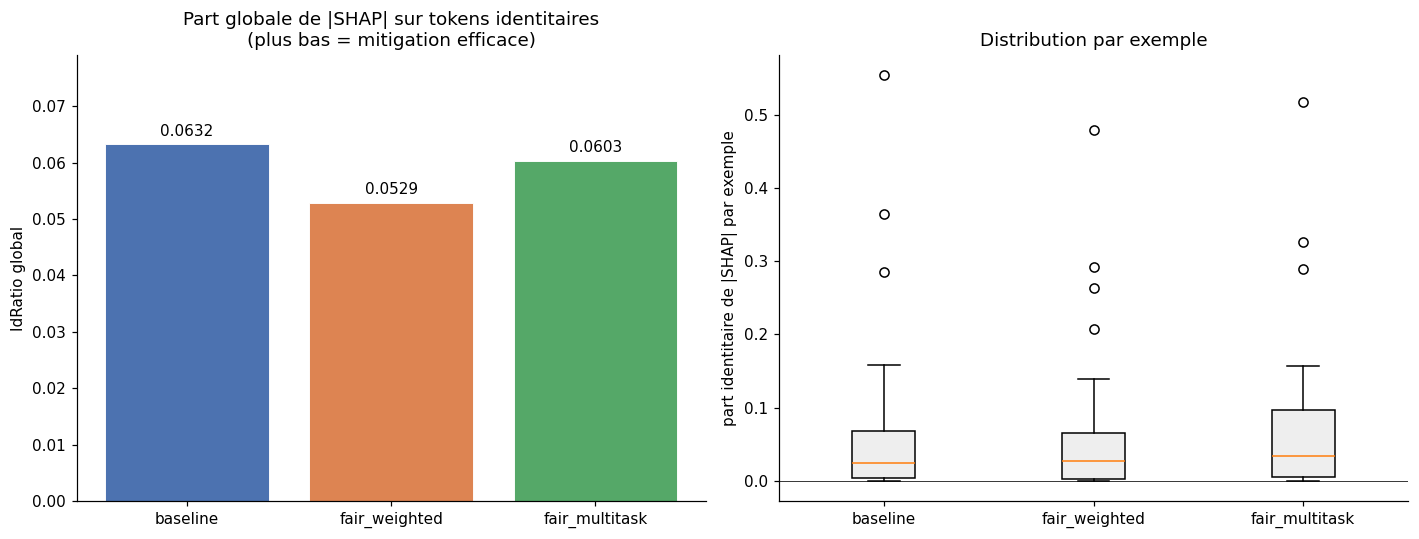

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\shap_id_ratio_comparison.png


In [22]:
labels_in = list(results.keys())
ratios = [results[l]["agg"]["id_global_ratio"] for l in labels_in]
shares = [results[l]["agg"]["example_id_share"] for l in labels_in]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Barres : IdRatio global
COLORS = {"baseline": "#4C72B0", "fair_weighted": "#DD8452", "fair_multitask": "#55A868"}
bar_colors = [COLORS[l] for l in labels_in]
ax1.bar(labels_in, ratios, color=bar_colors, edgecolor="white", linewidth=0.6)
ax1.set_ylabel("IdRatio global")
ax1.set_title(f"Part globale de |SHAP| sur tokens identitaires\n(plus bas = mitigation efficace)")
for i, v in enumerate(ratios):
    ax1.text(i, v + 0.001, f"{v:.4f}", ha="center", va="bottom", fontsize=10)
ax1.set_ylim(0, max(ratios) * 1.25)

# Box-plot par exemple
ax2.boxplot(shares, labels=labels_in,
             patch_artist=True,
             boxprops=dict(facecolor="#EEE"))
for patch, lbl in zip(ax2.artists if hasattr(ax2, "artists") else [], labels_in):
    patch.set_facecolor(COLORS[lbl])
ax2.set_ylabel("part identitaire de |SHAP| par exemple")
ax2.set_title("Distribution par exemple")
ax2.axhline(0, color="black", lw=0.5)

plt.tight_layout()
fig_path = FIGURES_DIR / "shap_id_ratio_comparison.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure : {fig_path}")


In [23]:
# Top-K tokens par modèle (moyenne |SHAP|), avec marquage identitaire
TOP_K = 25

token_tables = {}
for label in labels_in:
    tm = results[label]["agg"]["token_mean_abs"]
    # filtre tokens triviaux (mots vides, ponctuations résiduelles)
    STOPLIKE = {"the", "a", "an", "of", "to", "in", "is", "and", "or", "but",
                 "be", "for", "on", "with", "as", "by", "at", "this", "that",
                 "it", "its", "are", "was", "were", "have", "has", "had",
                 "i", "you", "we", "they", "not", "no", "so", "do", "does",
                 "did", "if", "than", "then", "there", "from", "what", "who"}
    rows = [(t, v) for t, v in tm.items() if t not in STOPLIKE and len(t) > 1]
    rows.sort(key=lambda kv: -kv[1])
    df_top = pd.DataFrame(rows[:TOP_K], columns=["token", "mean_abs_shap"])
    df_top["is_identity"] = df_top["token"].apply(lambda t: normalize_token(t) in IDENTITY_KEYWORDS)
    df_top["category"]    = df_top["token"].apply(token_category)
    token_tables[label] = df_top

for label in labels_in:
    n_id_in_top = int(token_tables[label]["is_identity"].sum())
    print(f"\n--- TOP {TOP_K} — {label}  ({n_id_in_top} tokens identitaires) ---")
    with pd.option_context("display.max_colwidth", 30):
        print(token_tables[label].to_string(index=False))



--- TOP 25 — baseline  (1 tokens identitaires) ---
    token  mean_abs_shap  is_identity    category
     damn       0.990212        False        None
    idiot       0.887087        False        None
     dumb       0.741140        False        None
     rape       0.590718        False        None
       yp       0.345190        False        None
      gay       0.275974         True sexual_lgbt
       id       0.238556        False        None
       io       0.235574        False        None
    drunk       0.142645        False        None
      die       0.124287        False        None
       oc       0.119969        False        None
    rites       0.119969        False        None
  liberal       0.084491        False        None
     ists       0.075337        False        None
  regards       0.072968        False        None
      rap       0.072780        False        None
      sex       0.060152        False        None
       ve       0.059926        False        Non

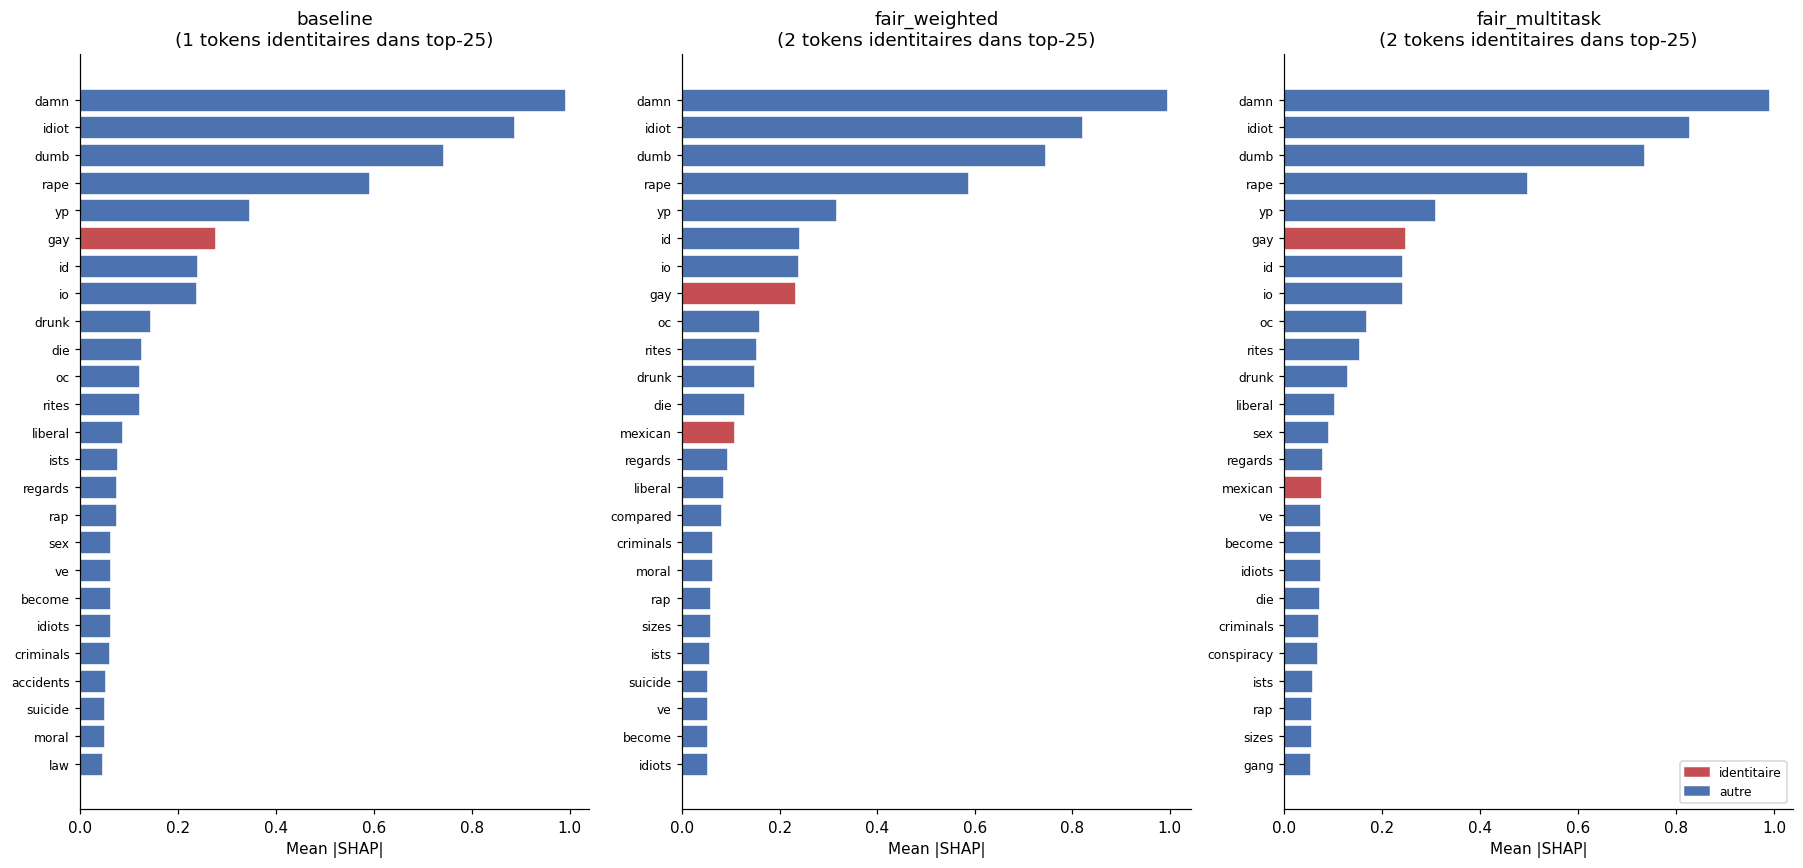

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\shap_top_tokens_comparison.png


In [24]:
fig, axes = plt.subplots(1, len(labels_in), figsize=(5.5 * len(labels_in), 8), sharex=False)
if len(labels_in) == 1:
    axes = [axes]

for ax, label in zip(axes, labels_in):
    df_top = token_tables[label].iloc[::-1]   # plus haut en haut
    colors = ["#C44E52" if x else "#4C72B0" for x in df_top["is_identity"]]
    ax.barh(np.arange(len(df_top)), df_top["mean_abs_shap"], color=colors, edgecolor="white", lw=0.4)
    ax.set_yticks(np.arange(len(df_top)))
    ax.set_yticklabels(df_top["token"], fontsize=8)
    ax.set_xlabel("Mean |SHAP|")
    ax.set_title(f"{label}\n({int(token_tables[label]['is_identity'].sum())} tokens identitaires dans top-{TOP_K})")

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color="#C44E52", label="identitaire"),
           mpatches.Patch(color="#4C72B0", label="autre")]
axes[-1].legend(handles=handles, loc="lower right", fontsize=8)
plt.tight_layout()
fig_path = FIGURES_DIR / "shap_top_tokens_comparison.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure : {fig_path}")


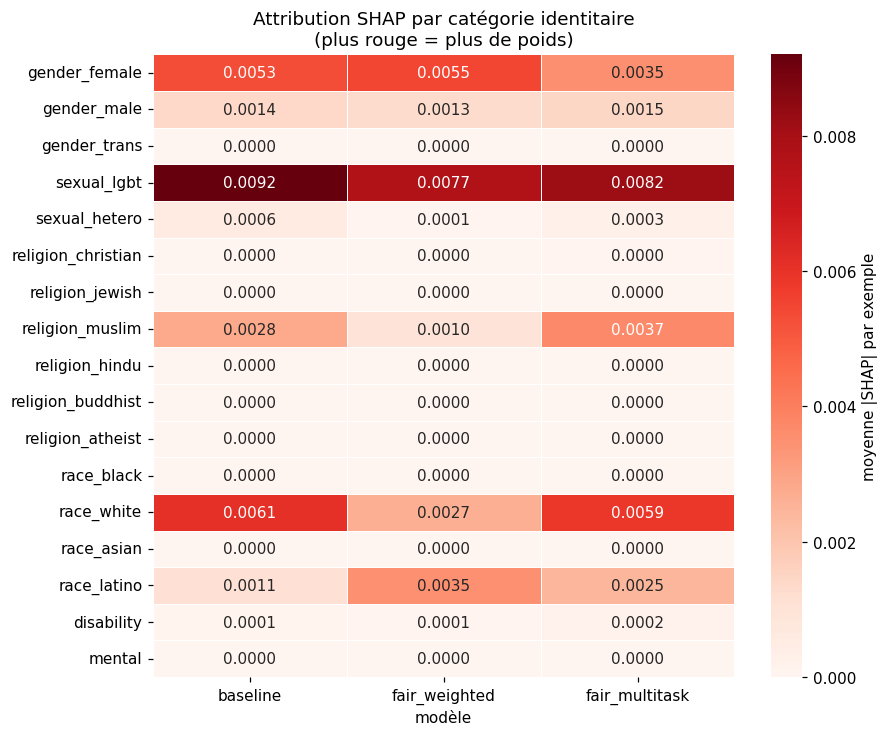

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\shap_category_heatmap.png


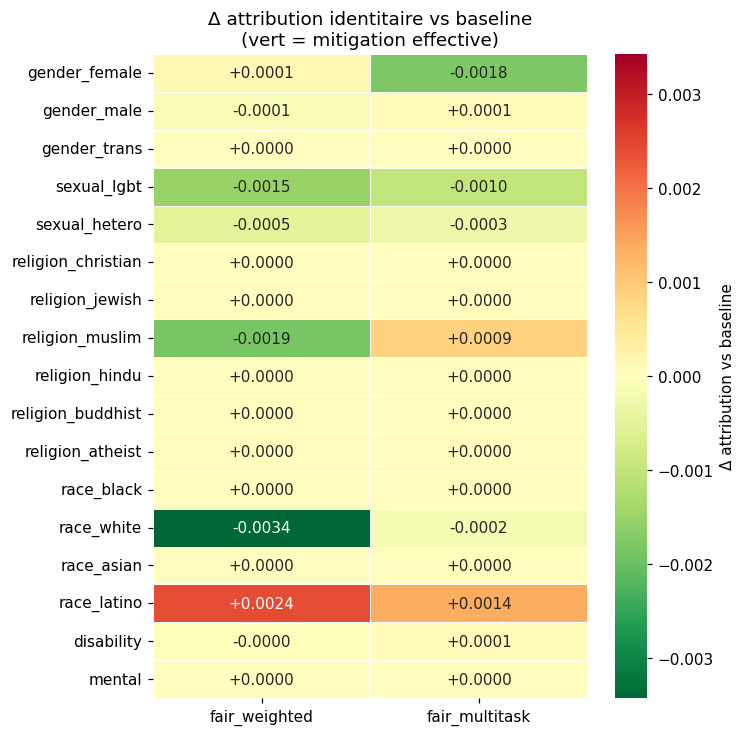

Figure : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\figures\shap_category_delta.png


In [25]:
# Heatmap : somme |SHAP| par catégorie identitaire × modèle (normalisée par nb exemples)
all_cats = list(IDENTITY_LEXICON.keys())
heat_data = np.zeros((len(all_cats), len(labels_in)), dtype=float)
for j, label in enumerate(labels_in):
    pc = results[label]["agg"]["per_category"]
    for i, cat in enumerate(all_cats):
        if cat in pc:
            # somme |SHAP| / nb exemples = importance moyenne par exemple
            heat_data[i, j] = pc[cat]["sum_abs_shap"] / max(1, len(sample_df))

heat = pd.DataFrame(heat_data, index=all_cats, columns=labels_in)
fig, ax = plt.subplots(figsize=(1.4 * len(labels_in) + 4, max(4, 0.4 * len(all_cats))))
sns.heatmap(heat, annot=True, fmt=".4f", cmap="Reds",
            ax=ax, linewidths=0.4, cbar_kws={"label": "moyenne |SHAP| par exemple"})
ax.set_title("Attribution SHAP par catégorie identitaire\n(plus rouge = plus de poids)")
ax.set_ylabel(""); ax.set_xlabel("modèle")
plt.tight_layout()
fig_path = FIGURES_DIR / "shap_category_heatmap.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure : {fig_path}")

# Δ par catégorie (variantes − baseline)
if "baseline" in labels_in and len(labels_in) > 1:
    base_col = heat["baseline"]
    delta = heat.drop(columns=["baseline"]).subtract(base_col, axis=0)
    vmax = float(np.nanmax(np.abs(delta.values))) or 1e-3
    fig, ax = plt.subplots(figsize=(1.4 * len(delta.columns) + 4, max(4, 0.4 * len(all_cats))))
    sns.heatmap(delta, annot=True, fmt="+.4f", cmap="RdYlGn_r",
                center=0, vmin=-vmax, vmax=vmax,
                ax=ax, linewidths=0.4, cbar_kws={"label": "Δ attribution vs baseline"})
    ax.set_title("Δ attribution identitaire vs baseline\n(vert = mitigation effective)")
    ax.set_ylabel("")
    plt.tight_layout()
    fig_path = FIGURES_DIR / "shap_category_delta.png"
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print(f"Figure : {fig_path}")


## 7. Comparaisons locales — HTML waterfall side-by-side

On génère pour chaque exemple de l'échantillon un fichier HTML unique combinant les 3 cartes de saillance (baseline / A / B) côte à côte. Idéal pour le rapport : on visualise sur le même commentaire BPSN comment chaque modèle attribue le poids aux tokens.


In [26]:
def html_card(label: str, prob: float, html_inner: str, color: str) -> str:
    return f"""
    <div style="flex:1; min-width:0; border:1px solid #ddd; border-radius:6px; padding:10px;">
      <div style="font-weight:bold; color:{color};">{label}  —  P(toxic) = {prob:.3f}</div>
      <div style="font-size:13px; line-height:1.8; margin-top:6px;">{html_inner}</div>
    </div>
    """


COMBINED_DIR = SHAP_DIR / "side_by_side"
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

predict_fns = {}
# On recharge brièvement chaque modèle pour avoir les probas exactes par exemple
for label in labels_in:
    print(f"  Reload {label} pour probas …")
    m, t = load_model(label)
    predict_fns[label] = (m, t, make_predict_fn(m, t))

# Calcul des probas par modèle × exemple
probs_per_model = {l: predict_fns[l][2](np.array(texts_sample)) for l in labels_in}
# (les modèles restent en mémoire ; on les libère plus tard)

# Construction des HTML combinés
for i in range(len(texts_sample)):
    cards = []
    for label in labels_in:
        html_path = SHAP_LOCAL_DIR / label / f"shap_{i:03d}.html"
        try:
            inner = html_path.read_text(encoding="utf-8")
        except FileNotFoundError:
            inner = "<i>HTML manquant</i>"
        cards.append(html_card(label, float(probs_per_model[label][i]), inner, COLORS[label]))

    title = f"Exemple #{i:03d}  ·  groupe {groups_sample[i]}  ·  vrai_label = {labels_sample[i]}"
    raw_text = _html.escape(texts_sample[i])
    page = f"""<!doctype html><meta charset="utf-8"><title>{title}</title>
    <body style="font-family: -apple-system, Segoe UI, sans-serif; margin:18px; max-width:1400px;">
      <h3 style="margin:0 0 4px 0;">{title}</h3>
      <pre style="background:#f6f6f6; padding:8px; border-radius:4px; white-space:pre-wrap;">{raw_text}</pre>
      <div style="display:flex; gap:12px; margin-top:12px;">{''.join(cards)}</div>
    </body>"""
    (COMBINED_DIR / f"compare_{i:03d}_{groups_sample[i]}.html").write_text(page, encoding="utf-8")

# Libère les modèles rechargés
for label in list(predict_fns.keys()):
    m, t, _ = predict_fns.pop(label)
    del m, t
free_cuda()

print(f"HTML side-by-side écrits dans : {COMBINED_DIR}")
print(f"  Ex : {sorted(COMBINED_DIR.glob('*.html'))[0].name}")


  Reload baseline pour probas …
  Reload fair_weighted pour probas …
  Reload fair_multitask pour probas …
HTML side-by-side écrits dans : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\shap\side_by_side
  Ex : compare_000_0_1.html


## 8. Sauvegarde + diagnostic


In [27]:
# Synthèse machine-readable
synth = {
    "config": {
        "seed": SEED, "max_length": MAX_LEN, "n_examples": N_EXAMPLES,
        "max_evals": MAX_EVALS, "quotas": QUOTAS,
    },
    "vocab": {
        "n_keywords": len(IDENTITY_KEYWORDS),
        "categories": {k: sorted(v) for k, v in IDENTITY_LEXICON.items()},
    },
    "models": {},
}
for label in labels_in:
    agg = results[label]["agg"]
    synth["models"][label] = {
        "id_global_ratio": float(agg["id_global_ratio"]),
        "example_id_share_mean":   float(agg["example_id_share"].mean()),
        "example_id_share_median": float(np.median(agg["example_id_share"])),
        "example_id_share_max":    float(agg["example_id_share"].max()),
        "per_category": agg["per_category"],
        "top_tokens": token_tables[label].head(TOP_K).to_dict(orient="records"),
        "n_identity_in_top25": int(token_tables[label]["is_identity"].sum()),
    }

# Deltas vs baseline
if "baseline" in synth["models"]:
    base = synth["models"]["baseline"]
    deltas = {}
    for label in labels_in:
        if label == "baseline":
            continue
        m = synth["models"][label]
        deltas[label] = {
            "delta_id_global_ratio":     m["id_global_ratio"] - base["id_global_ratio"],
            "delta_share_mean":          m["example_id_share_mean"] - base["example_id_share_mean"],
            "delta_n_identity_in_top25": m["n_identity_in_top25"] - base["n_identity_in_top25"],
        }
    synth["deltas_vs_baseline"] = deltas

out_path = METRICS_DIR / "shap_audit_metrics.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(synth, f, indent=2, default=float)
print(f"Synthèse SHAP : {out_path}")

# Récapitulatif lisible
print("\n=== RÉCAPITULATIF AUDIT SHAP ===")
print(f"{'Modèle':<18} {'IdRatio':>10} {'mean share':>12} {'#id top25':>10}")
for label in labels_in:
    m = synth["models"][label]
    print(f"{label:<18} {m['id_global_ratio']:>10.4f} "
          f"{m['example_id_share_mean']:>12.4f} {m['n_identity_in_top25']:>10d}")
if "deltas_vs_baseline" in synth:
    print()
    for label, d in synth["deltas_vs_baseline"].items():
        sign = "↘" if d["delta_id_global_ratio"] < 0 else "↗"
        print(f"  Δ {label:<14} {sign} IdRatio = {d['delta_id_global_ratio']:+.4f} | "
              f"share = {d['delta_share_mean']:+.4f} | top25 = {d['delta_n_identity_in_top25']:+d}")


Synthèse SHAP : C:\Users\moura\Documents\Studies\TP\IA_Responsable\projet\AI-Fairness-Jigsaw\reports\metrics\shap_audit_metrics.json

=== RÉCAPITULATIF AUDIT SHAP ===
Modèle                IdRatio   mean share  #id top25
baseline               0.0632       0.0699          1
fair_weighted          0.0529       0.0668          2
fair_multitask         0.0603       0.0775          2

  Δ fair_weighted  ↘ IdRatio = -0.0104 | share = -0.0031 | top25 = +1
  Δ fair_multitask ↘ IdRatio = -0.0029 | share = +0.0076 | top25 = +1


### Lecture des résultats SHAP

**Indicateurs de mitigation efficace** :
- `IdRatio(fair) < IdRatio(baseline)` ⇒ les modèles fair attribuent moins de poids aux tokens identitaires.
- Δ `n_identity_in_top25` négatif ⇒ moins de tokens identitaires parmi les top features.
- Sur la heatmap des catégories : les cases rouges intenses du baseline (typiquement `religion_muslim`, `sexual_lgbt`, `race_black`) **doivent pâlir** chez A et B.

**Si IdRatio ne baisse pas significativement** :
- Variante A : augmenter `λ_FP` (0.5 ou 1.0).
- Variante B : augmenter `α_identity` (0.2 ou 0.3).
- Considérer une mitigation **adversariale** (gradient reversal) comme variante C.

**Cas locaux à analyser dans le rapport** :
- Choisir 2-3 commentaires BPSN (group `0_1`) où le baseline prédit faussement toxique et où le fair model corrige : c'est la **preuve qualitative** du débiais.

### Artefacts produits

```
reports/
├── shap/
│   ├── sample_ids.json
│   ├── local_html/{baseline, fair_weighted, fair_multitask}/shap_NNN.html
│   └── side_by_side/compare_NNN_{group}.html      ← clé pour le rapport
├── metrics/
│   └── shap_audit_metrics.json                   ← exporté en synthèse P5
└── figures/
    ├── shap_id_ratio_comparison.png
    ├── shap_top_tokens_comparison.png
    ├── shap_category_heatmap.png
    └── shap_category_delta.png
```

### Prochaine étape : Phase 4 — Robustesse

→ Notebook `05_robustness.ipynb` :
1. **Bruit caractère contrôlé** sur l'ensemble test : typos (5%), random case (20%), no-whitespace.
   - Mesurer ΔAUC, ΔECE, flip-rate (fraction de prédictions changées).
2. **Attaque sémantique TextFooler** (TextAttack) sur 500 commentaires toxiques bien classés.
   - ASR, nb mots modifiés, similarité USE.
3. Comparaison **baseline vs fair-A vs fair-B** : la mitigation aggrave-t-elle, neutralise-t-elle ou améliore-t-elle la robustesse ?
